### Use old version of AiZynthFinder (e.g. 4.3.2)

In [20]:
from aizynthfinder.interfaces import AiZynthApp
from cgr_clustering.aizynth_converter import extract_routes_from_tree, filter_unique_routes
from tqdm import tqdm
import pickle
from synplan.chem.reaction_routes.visualisation import cgr_display
from IPython.display import display, HTML, SVG

### Routes Generation

In [2]:
smiles = 'N#CC1(c2ccc(NC(=O)c3cccnc3NCc3ccncc3)cc2)CCCC1'

In [3]:
# Load the AiZynthFinder application
app = AiZynthApp("config.yml")

Loading template-based expansion policy model from ./data/uspto_model.onnx to uspto
Loading templates from ./data/uspto_templates.csv to uspto
Loading template-based expansion policy model from ./data/uspto_ringbreaker_model.onnx to ringbreaker
Loading templates from ./data/uspto_ringbreaker_templates.csv.gz to ringbreaker
Loading filter policy model from ./data/uspto_filter_model.onnx to uspto
Loading stock from InMemoryInchiKeyQuery to askcos


Text(value='', continuous_update=False, description='SMILES')

Output(layout=Layout(border_bottom='1px solid silver', border_left='1px solid silver', border_right='1px solid…

Output(layout=Layout(border_bottom='1px solid silver', border_left='1px solid silver', border_right='1px solid…

Output(layout=Layout(border_bottom='1px solid silver', border_left='1px solid silver', border_right='1px solid…

Output(layout=Layout(border_bottom='1px solid silver', border_left='1px solid silver', border_right='1px solid…

### --- Route Extraction and Filtering ---

In [4]:
route_collections = extract_routes_from_tree(app)
print(f"Extracted {len(route_collections)} route collections.")
filtered_route_collection = filter_unique_routes(route_collections)
print(f"Filtered to {len(filtered_route_collection)} unique routes.")

Extracted 712 route collections.
Filtered to 230 unique routes.


### --- RouteCGR and SB-CGRs ---

In [5]:
from cgr_clustering.aizynth_converter import extract_all_route_cgrs
from synplan.chem.reaction_routes.route_cgr import compose_all_sb_cgrs

In [6]:
route_cgrs_dict = extract_all_route_cgrs(filtered_route_collection)

230it [00:32,  7.02it/s]


In [7]:
sb_cgrs_dict = compose_all_sb_cgrs(route_cgrs_dict)

### Clustering by SB-CGR

In [8]:
from synplan.chem.reaction_routes.clustering import cluster_routes

sbp_clusters = cluster_routes(sb_cgrs_dict)
print("Number of SB groups:", len(sbp_clusters))

Number of SB groups: 24


In [ ]:
for i, group in sbp_clusters.items():
    print(i)
    sb_cgr = group['sb_cgr']
    sb_cgr.clean2d()
    display(SVG(cgr_display(sb_cgr)))
    print(group['route_ids'])

### Fixing the mismapping output - SKIP this part if mapping is okay

In [9]:
from cgr_clustering.sb_clustering import *

In [10]:
sbp_groups_n = remap_final_cgrs(sbp_clusters, smiles)

In [11]:
verbose = True
clean_sbp_groups = map_error_fix(sbp_groups_n, verbose=verbose)
new_clusters = merge_identical_sb_cgr(clean_sbp_groups, verbose=verbose)
ren_clusters = renumber_clusters_by_strat_bonds(new_clusters)

Fixed error clusters: ['3.6', '4.2', '4.4', '5.4']
3.2 4.4 - merged
3.3 4.2 - merged


In [ ]:
for i, group in ren_clusters.items():
    print(i)
    sb_cgr = group['sb_cgr']
    sb_cgr.clean2d()
    display(sb_cgr)
    print(group['strat_bonds'])

In [12]:
len(ren_clusters)

22

### Results overlaping Comparison

In [13]:
from collections import defaultdict

cluster_arr = filtered_route_collection.cluster(len(ren_clusters), distances_model="ted") ### Important line
cluster_ted = defaultdict(list)
for idx, val in enumerate(cluster_arr):
    cluster_ted[val+1].append(idx)

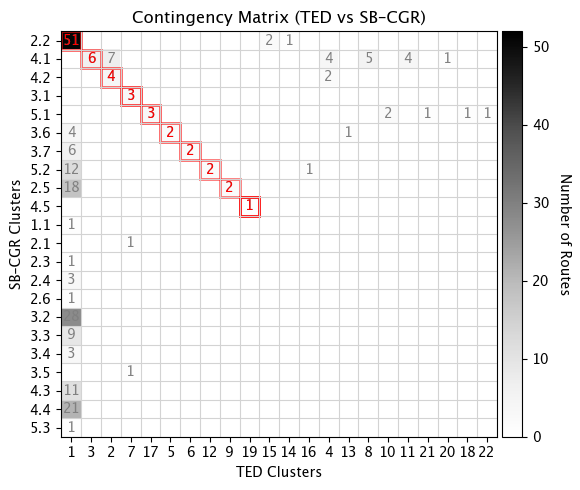

In [15]:
from cgr_clustering.comparing import *
from cgr_clustering.visualization import display_contingency_matrix

y_true, y_pred = calculate_similarity_metrics(ren_clusters, cluster_ted)
cm = compute_contingency_matrix(y_true, y_pred)
matched, avg_jaccard = match_clusters(ren_clusters, cluster_ted)
cm_sorted, matches = diagonalize_contingency(cm)
display_contingency_matrix(matches, cm_sorted, method='TED')

### Explore routes by IDs

Need to run image generetaion (might take a while)

In [16]:
images = filtered_route_collection.make_images()

In [23]:
from cgr_clustering.comparing import contingency_nodes


def show_routes_in_cell(sb_cgr_ind, ted_ind, first_n=10):
    sb_cgr = ren_clusters[sb_cgr_ind]['sb_cgr']
    sb_cgr.clean2d()
    display(SVG(cgr_display(sb_cgr)))
    routes_list = contingency_nodes(ren_clusters, cluster_ted, sb_cgr_ind, ted_ind) 
    print('Number of routes in cell', len(routes_list))
    print('Routes ids in AiZynthFinder list', routes_list)
    for route in routes_list[:first_n]:
        print('ID:',route)
        # display(route_collections[route].make_images()[0])
        display(images[route])   

Number of routes in cell 18
Routes ids in AiZynthFinder list [2, 3, 5, 7, 10, 17, 22, 27, 125, 126, 136, 137, 169, 170, 171, 183, 184, 195]
ID: 2


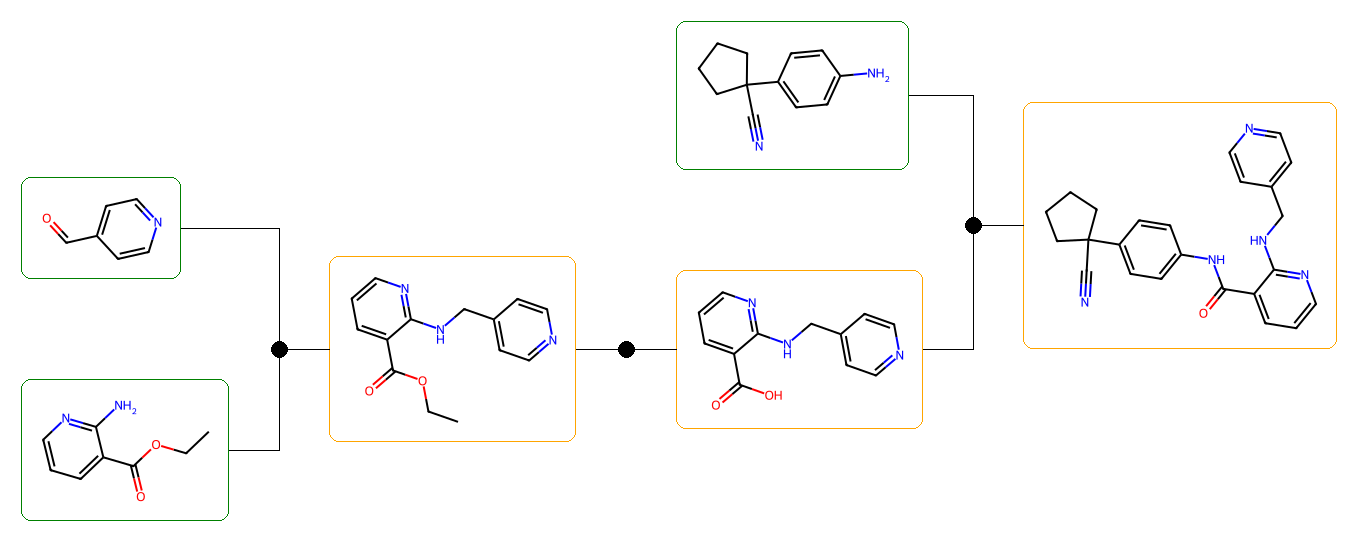

ID: 3


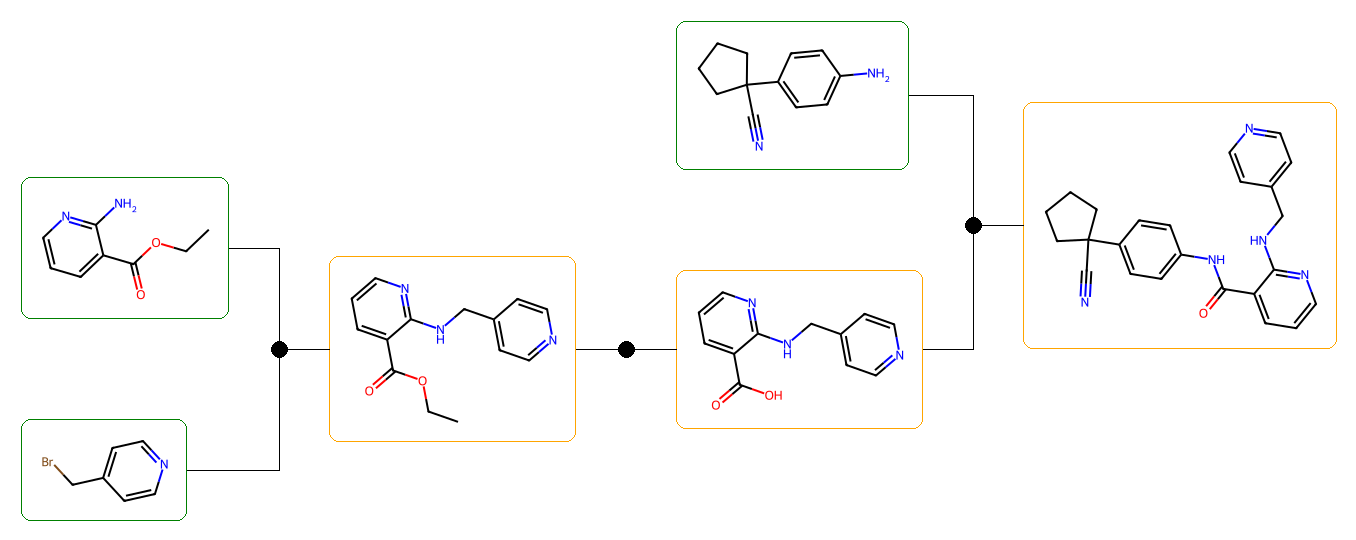

ID: 5


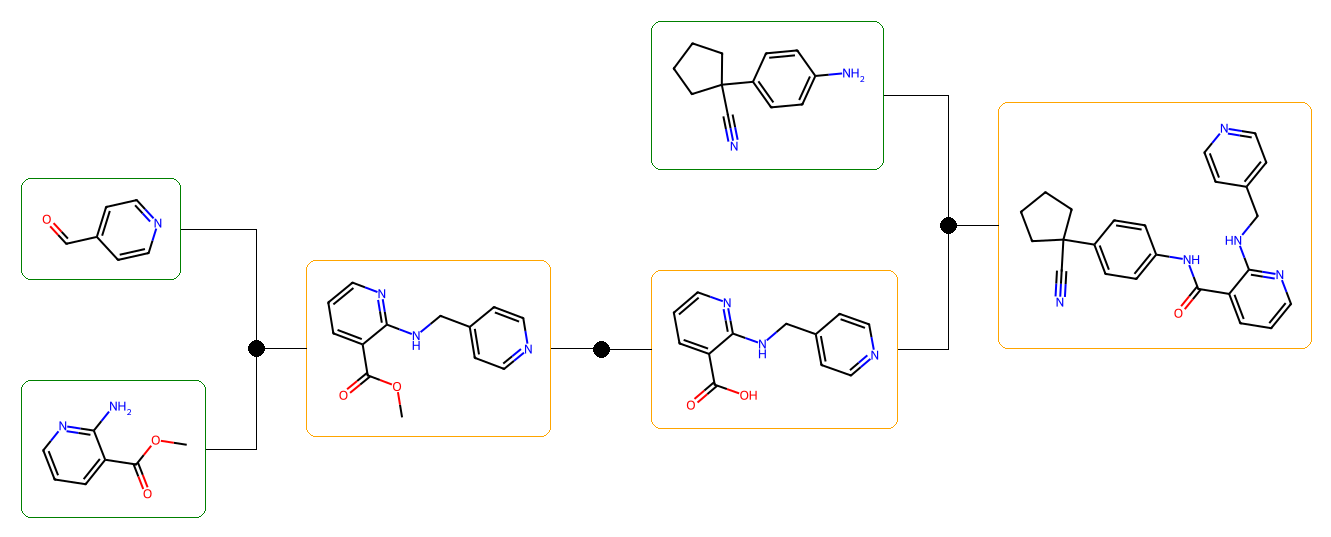

ID: 7


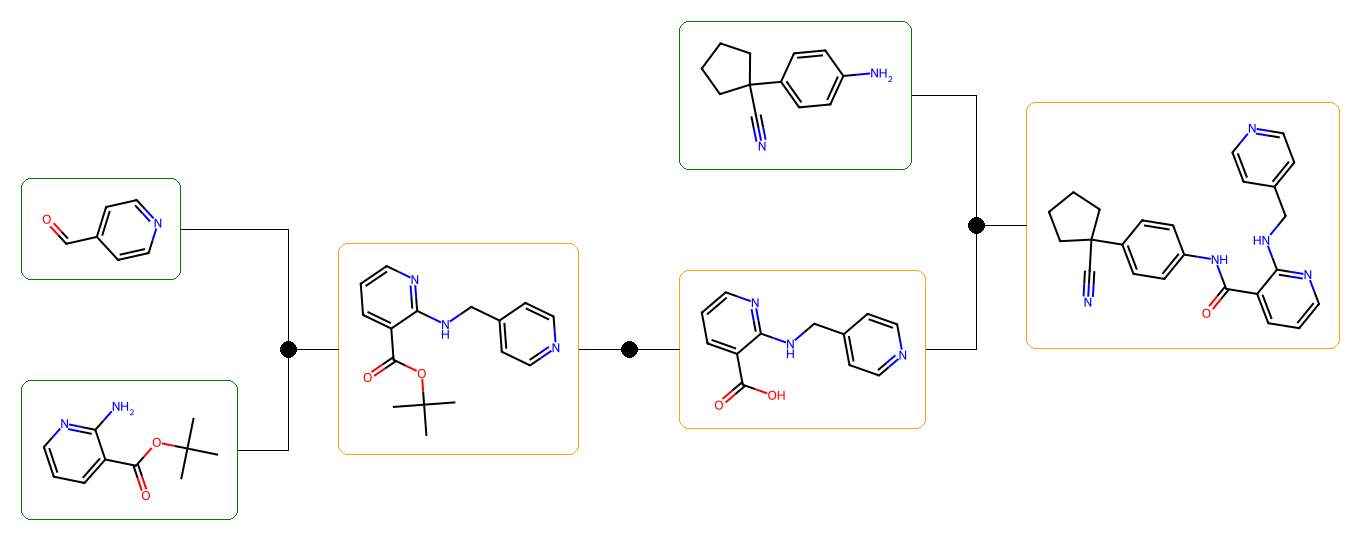

ID: 10


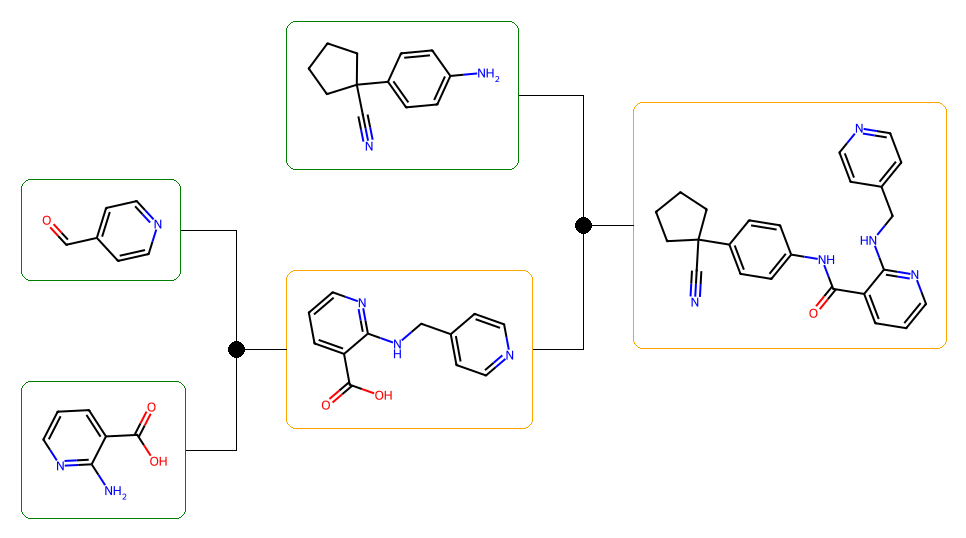

ID: 17


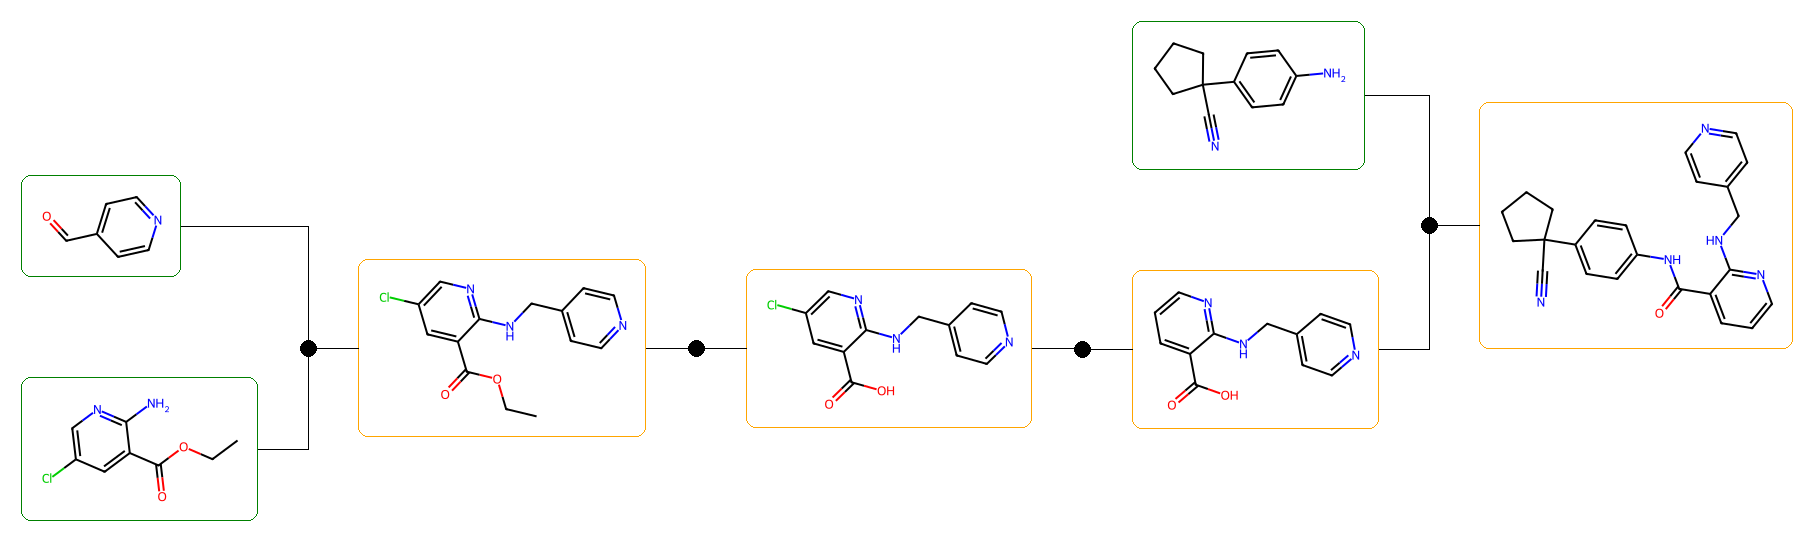

ID: 22


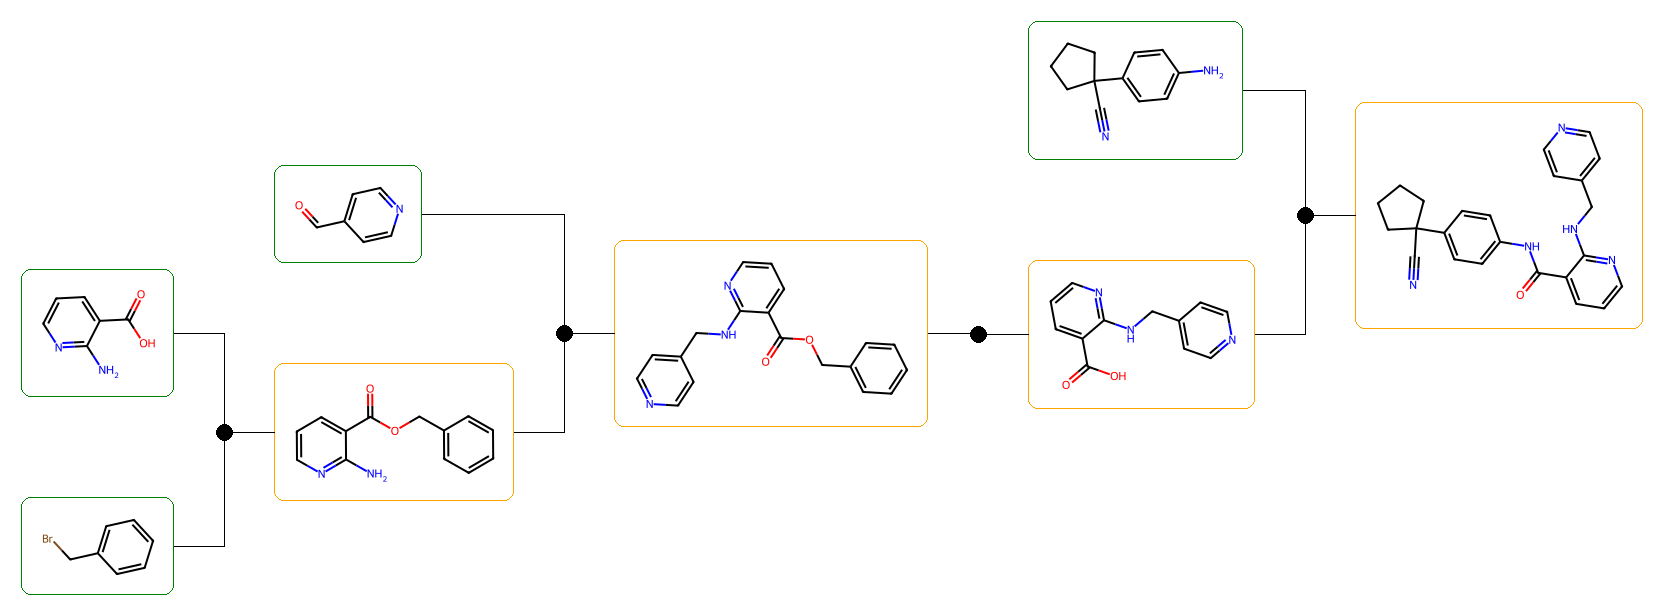

ID: 27


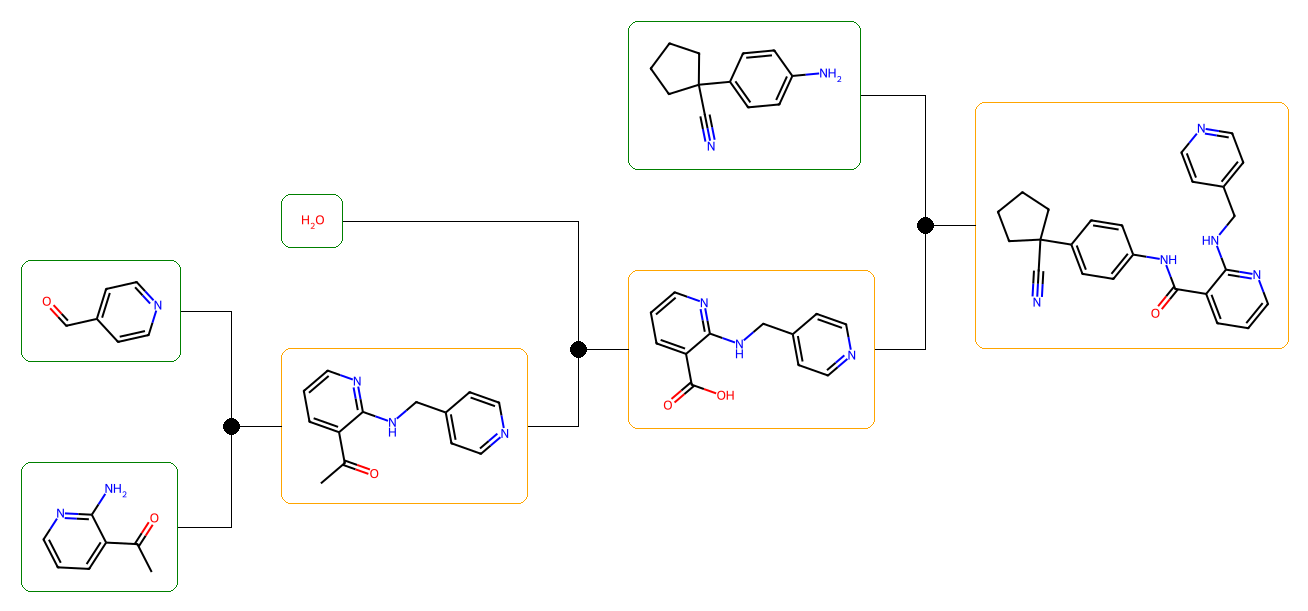

ID: 125


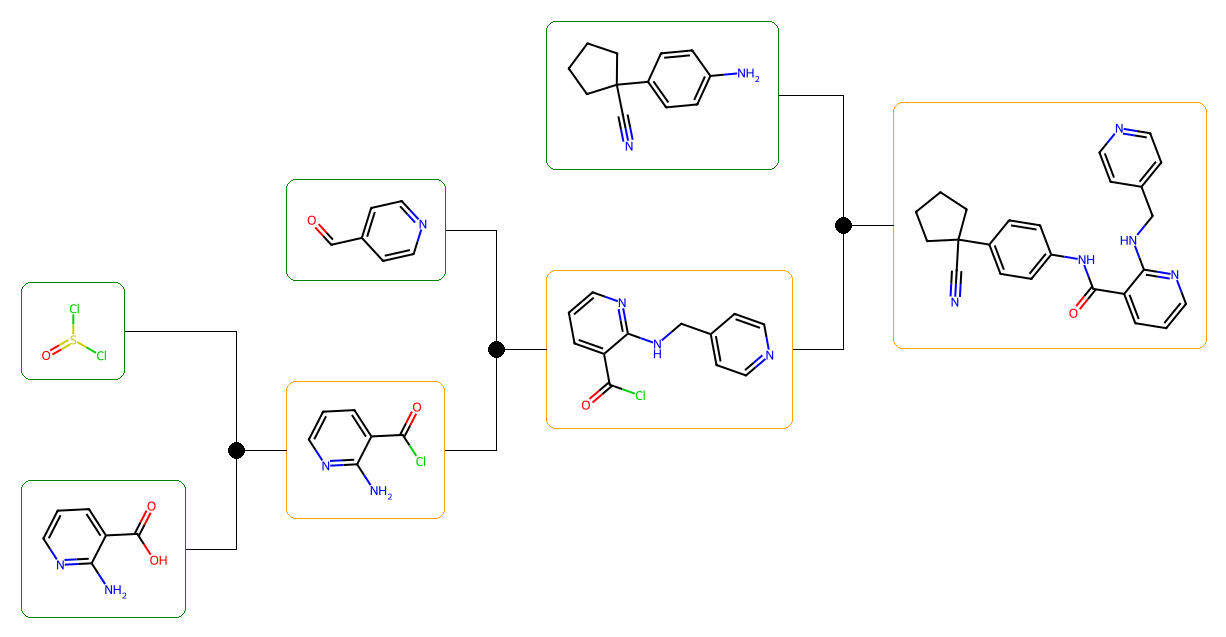

ID: 126


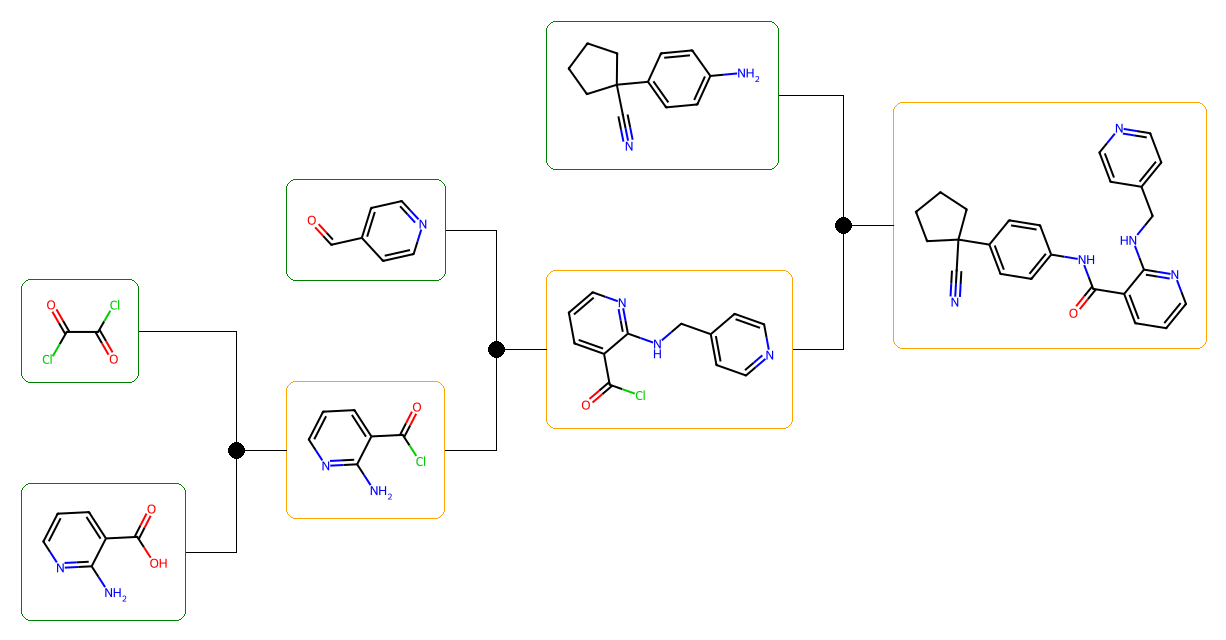

In [24]:
sb_cgr_ind = '2.5'
ted_ind = 1
show_routes_in_cell(sb_cgr_ind, ted_ind, first_n=10)

Number of routes in cell 21
Routes ids in AiZynthFinder list [35, 38, 39, 40, 41, 42, 48, 49, 50, 51, 55, 57, 70, 71, 72, 161, 162, 163, 165, 166, 167]
ID: 35


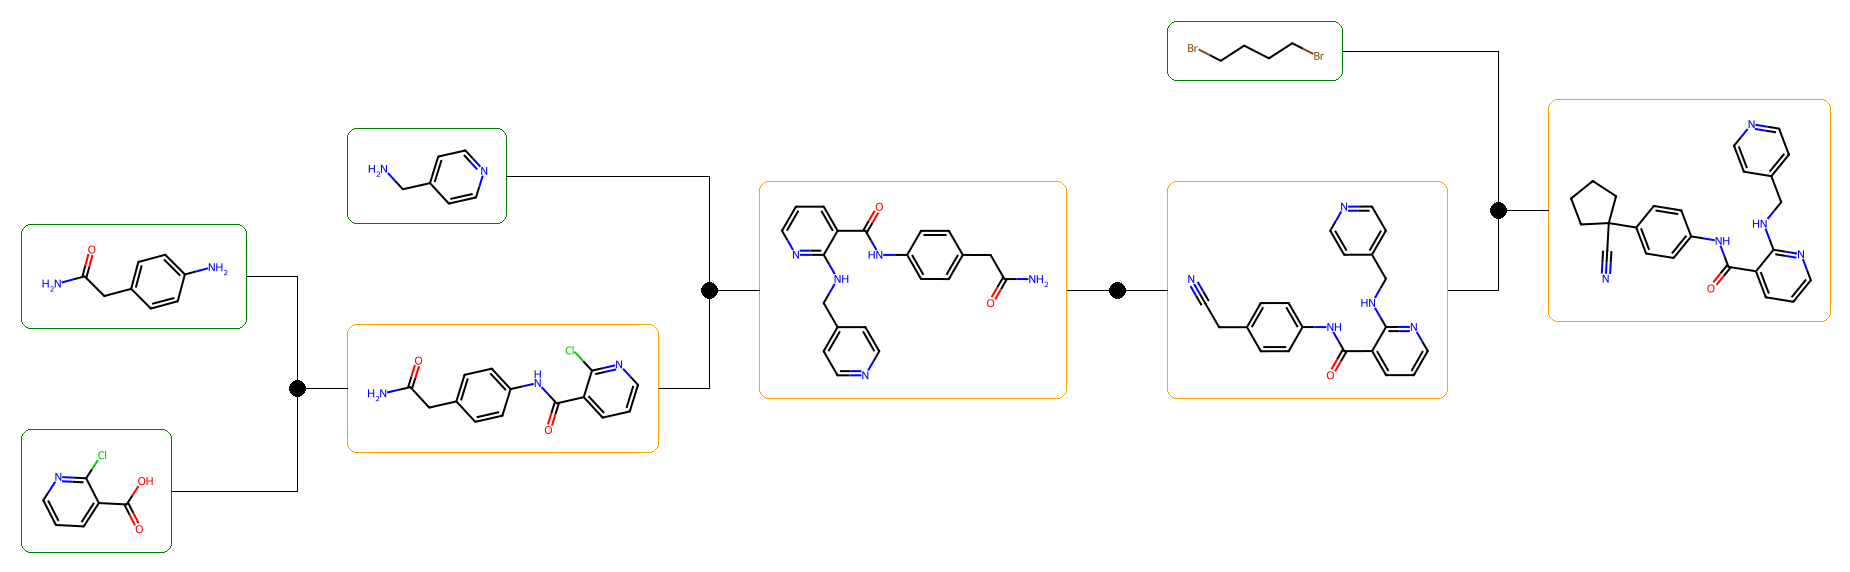

ID: 38


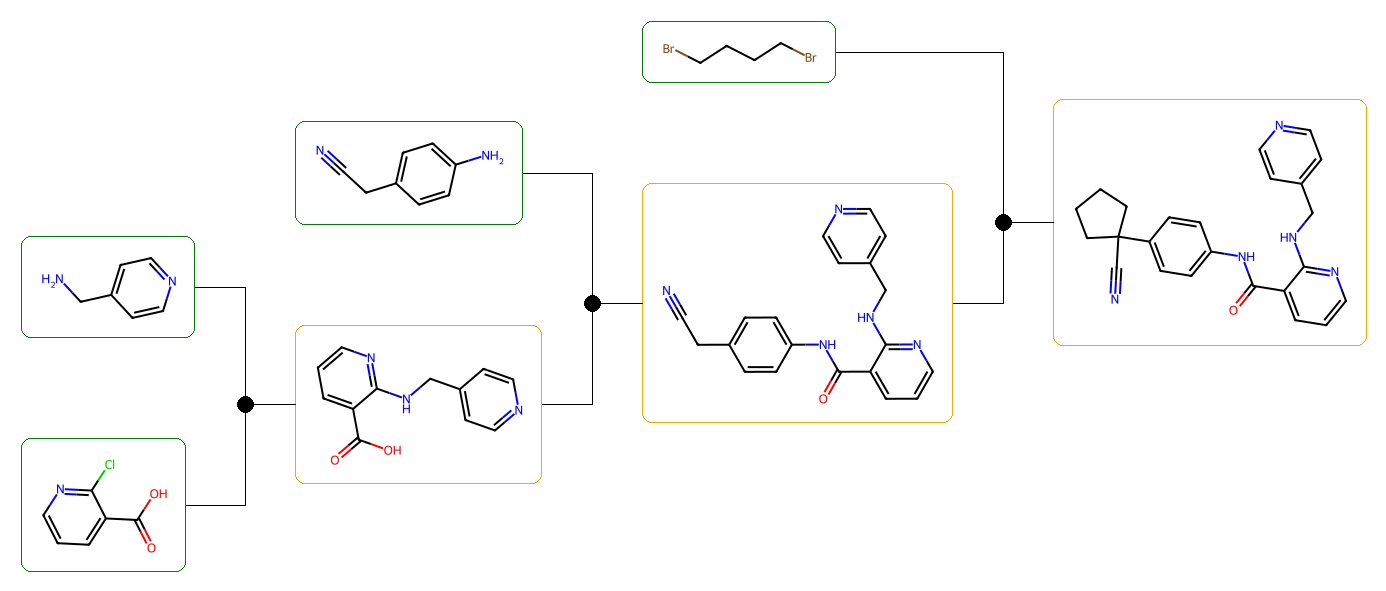

ID: 39


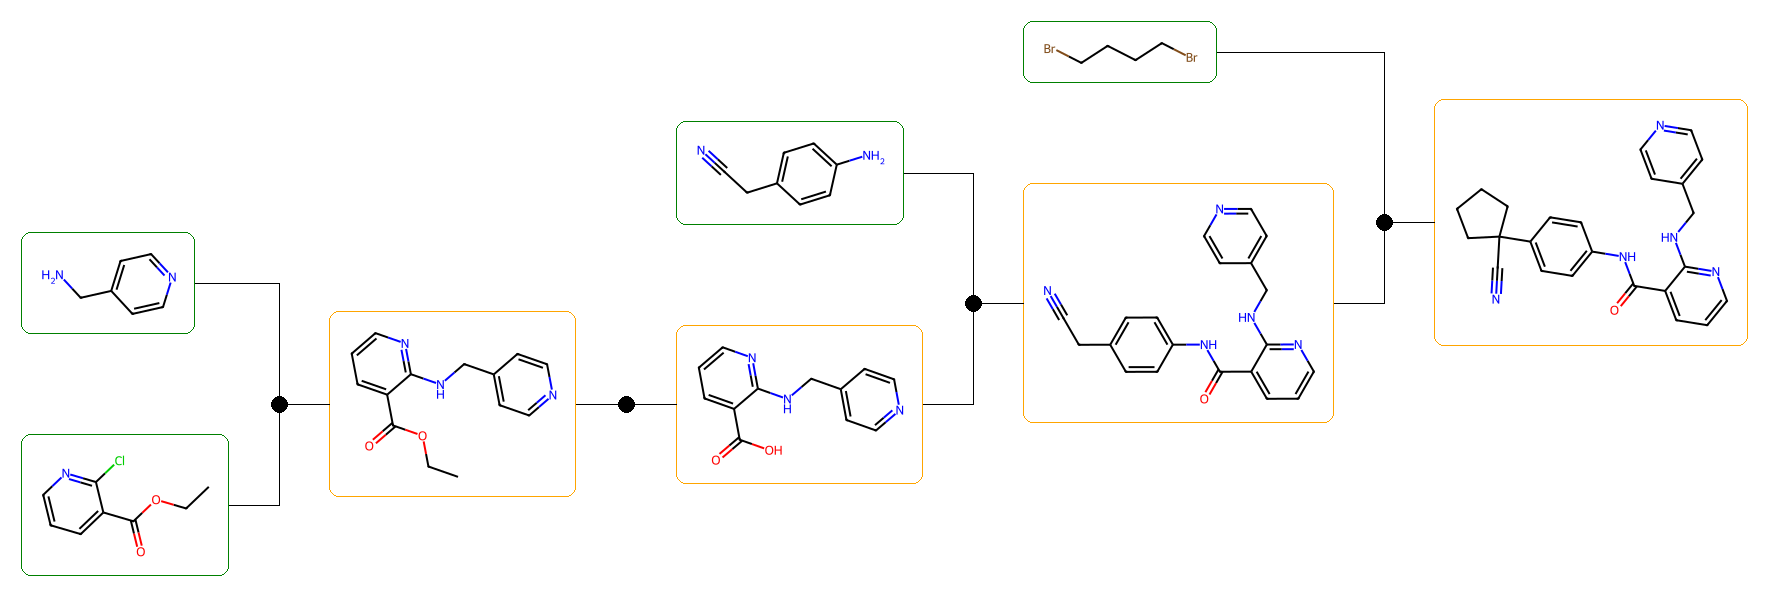

ID: 40


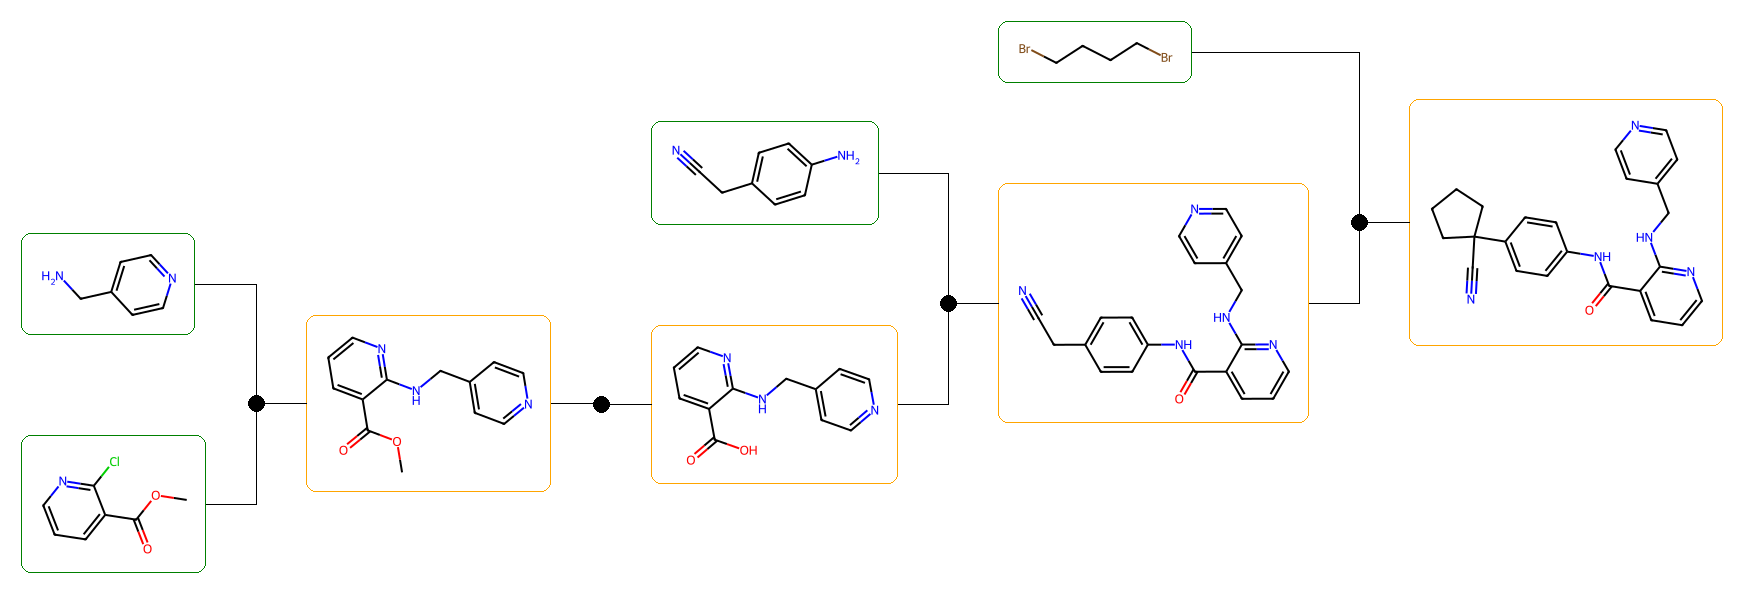

ID: 41


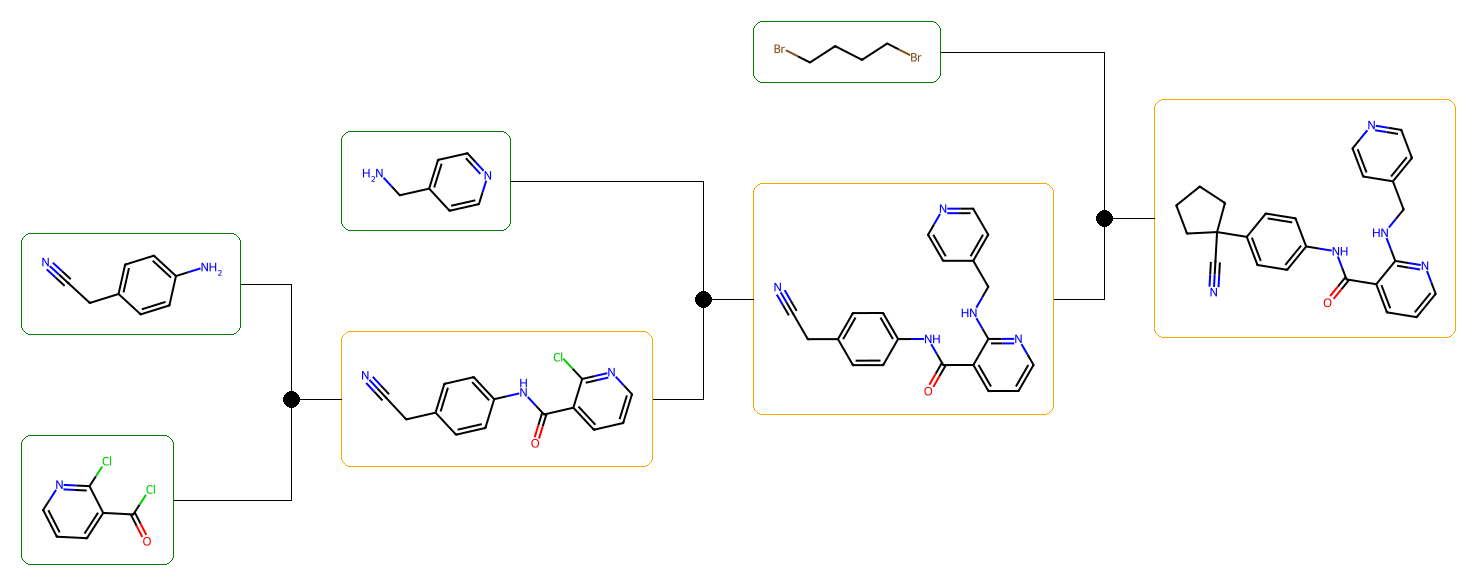

ID: 42


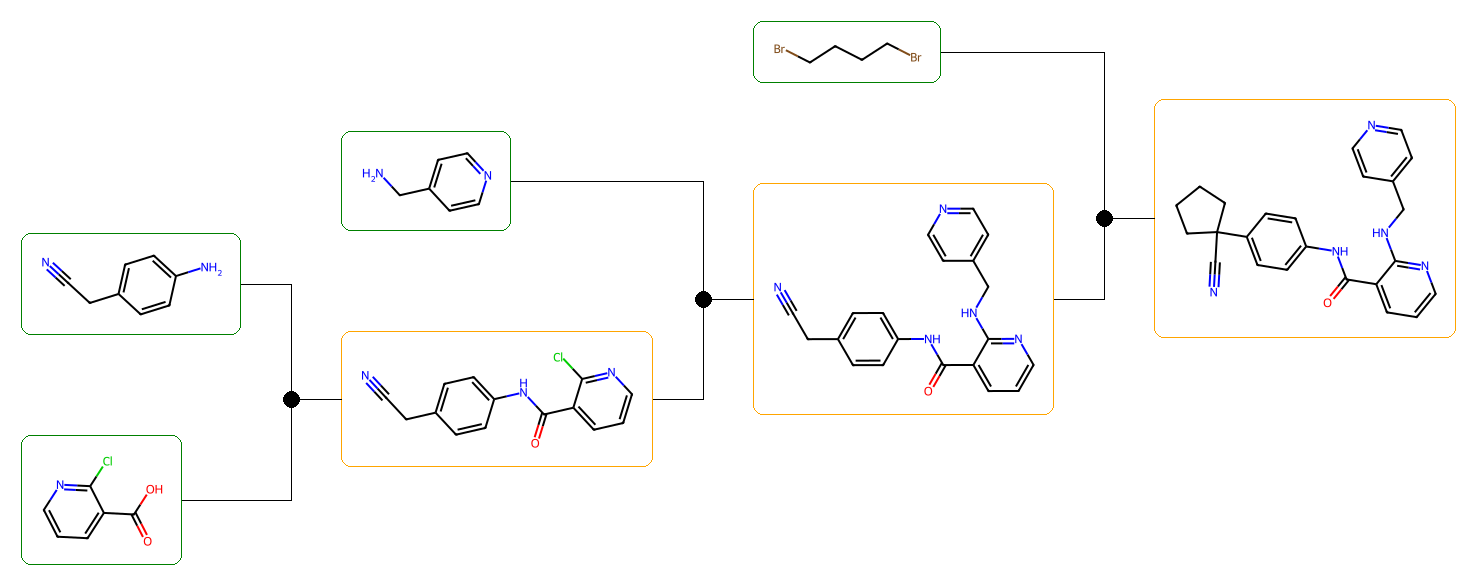

ID: 48


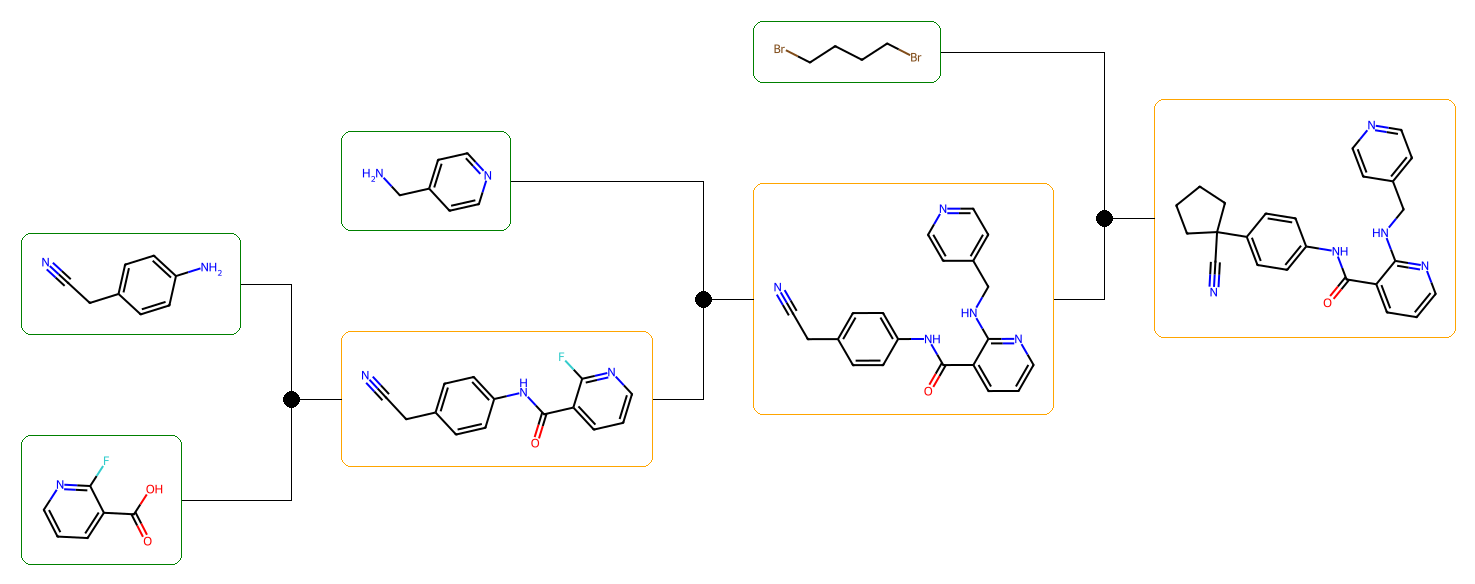

ID: 49


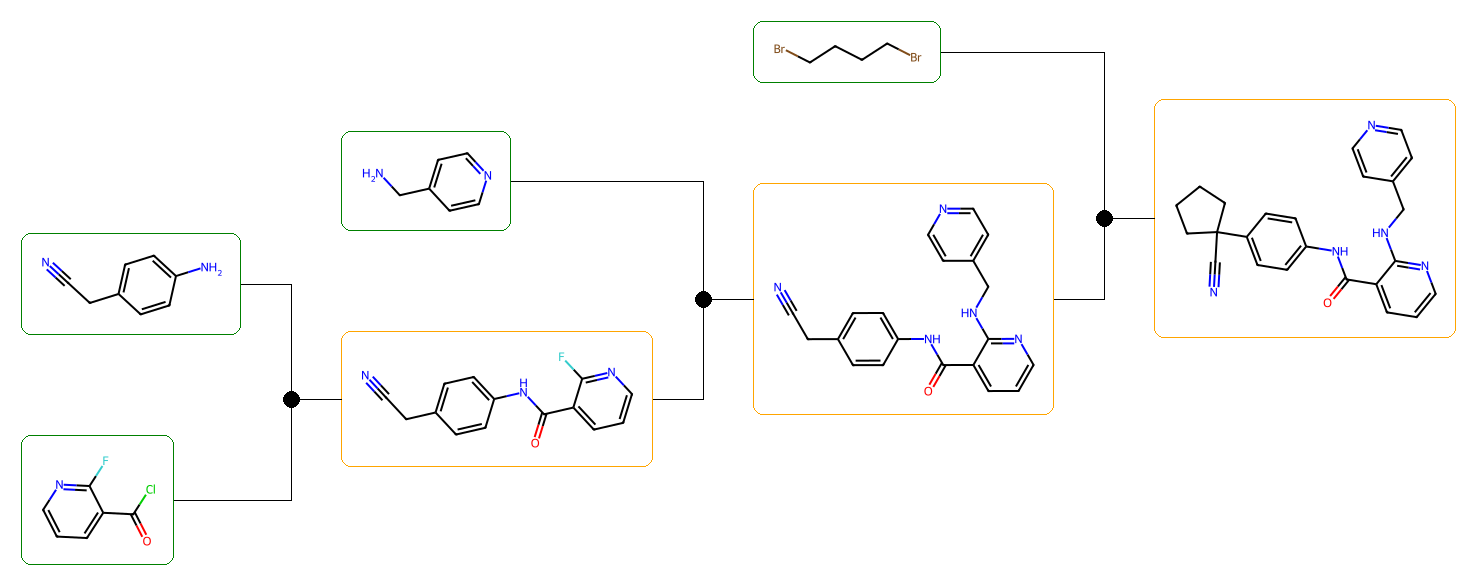

ID: 50


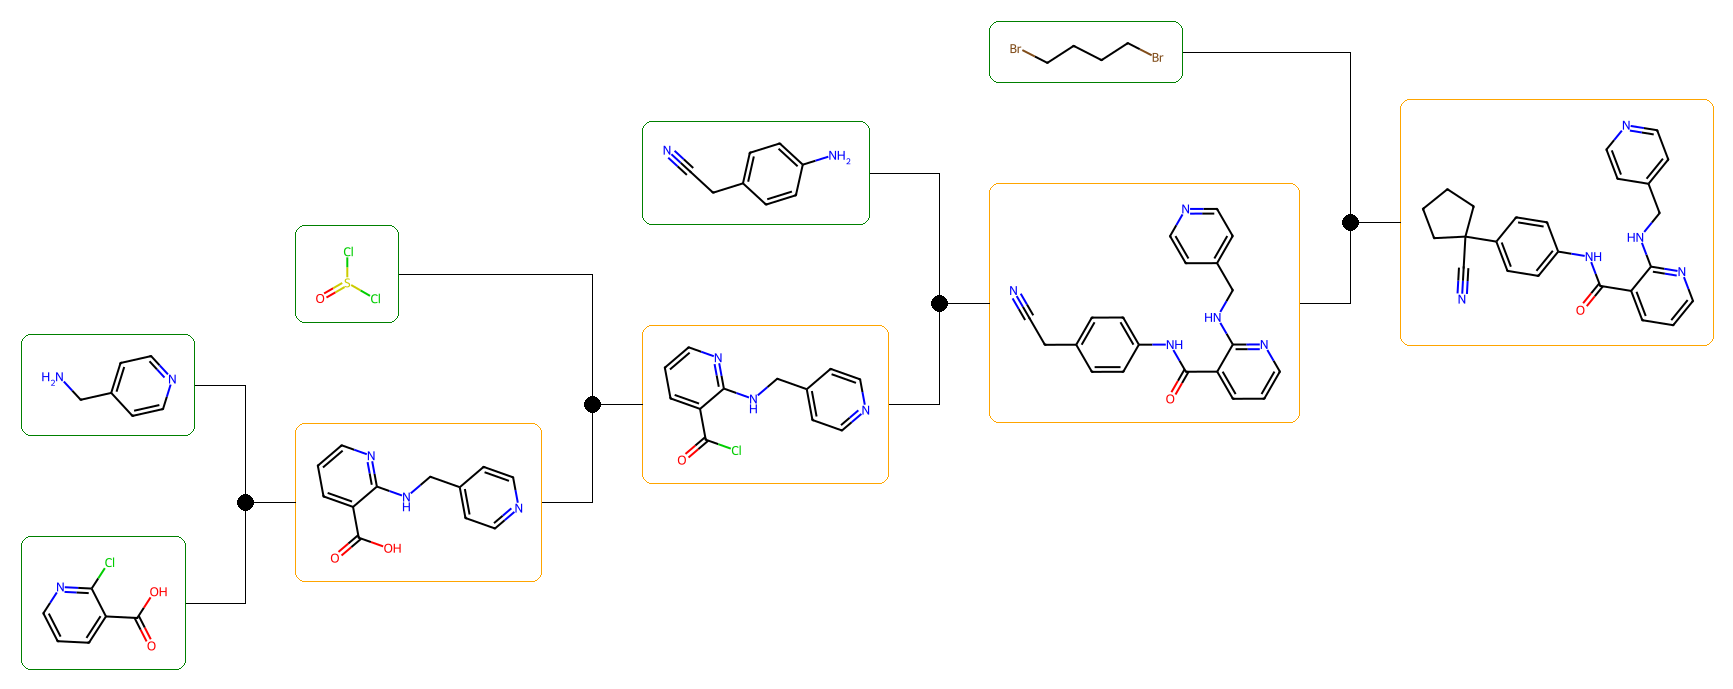

ID: 51


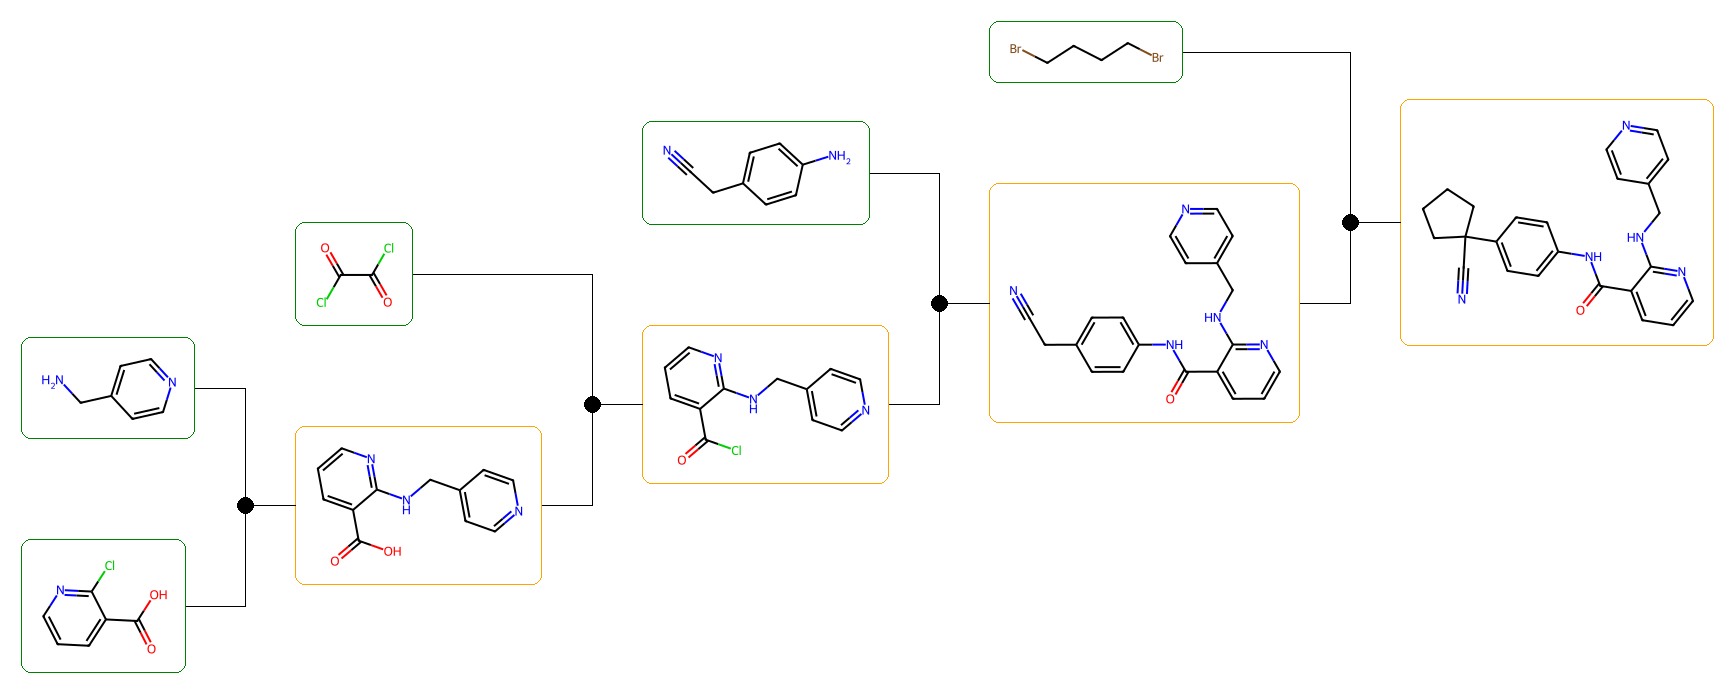

In [25]:
sb_cgr_ind = '4.4'
ted_ind = 1
show_routes_in_cell(sb_cgr_ind, ted_ind, first_n=10)

### For inter-comparison with other retorysnthteic tools' results (SynPlanner and ASKCOS)

In [26]:
# Result should same as for aizynth_clusters (from ATOM-BOND clustering)
pickle.dump(ren_clusters, open('./inter_comp_data/aizynth_sb_clusters_ted.pkl', 'wb'))